In [2]:
import numpy as np
from typing import List
import matplotlib.pyplot as plt

from model_ranking.utils import (
    load_h5,
    find_finetuning_result_paths,
    find_transfer_from_pred_path,
    is_ndarray
)

# Consistency Scores (Epoch Zero)

In [2]:
models_DO = [
    "EtoH_DO_a02_model1", 
    "EtoR_DO_a02_model1", 
    "EtoV_DO_a02_model1",
    "HtoE_DO_a02_model3",
    #"HtoE_DO_a04_model1",
    "HtoR_DO_a02_model1",
    "HtoV_DO_a02_model1",
    "RtoE_DO_a02_model1",
    "RtoH_DO_a02_model1",
    "RtoV_DO_a02_model1",
    "VtoE_DO_a02_model1",
    "VtoH_DO_a02_model1",
    "VtoR_DO_a02_model1",
]
paths = find_finetuning_result_paths(models_DO, output_folder="pseudo_labeler")

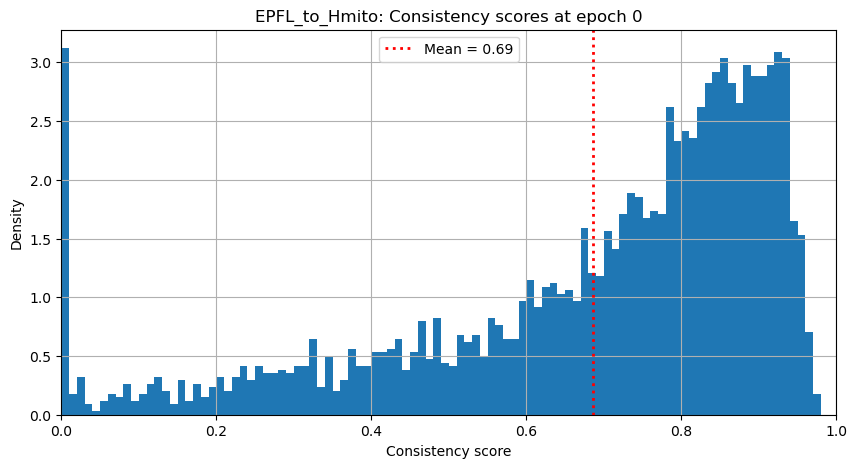

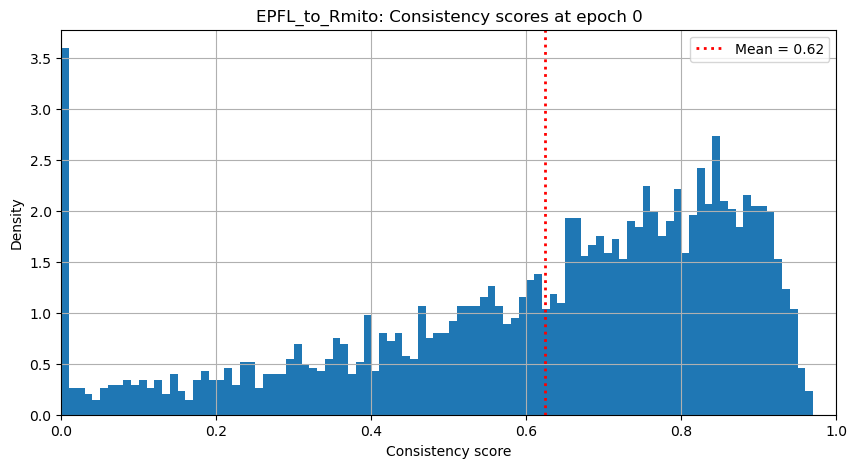

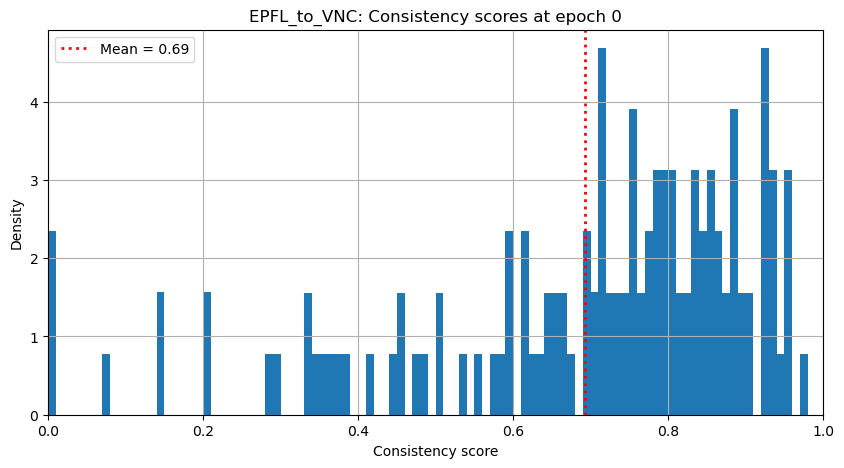

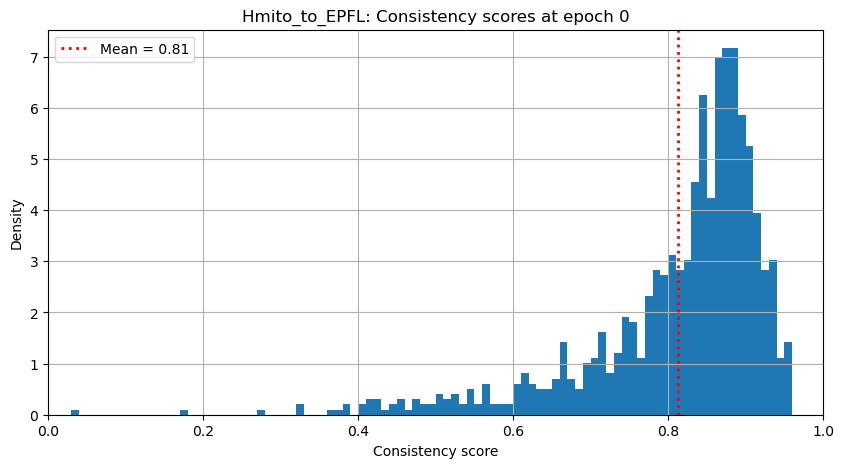

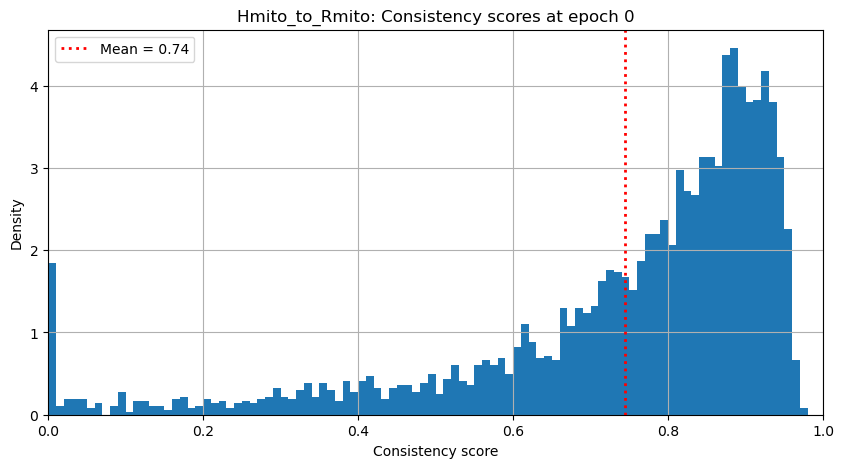

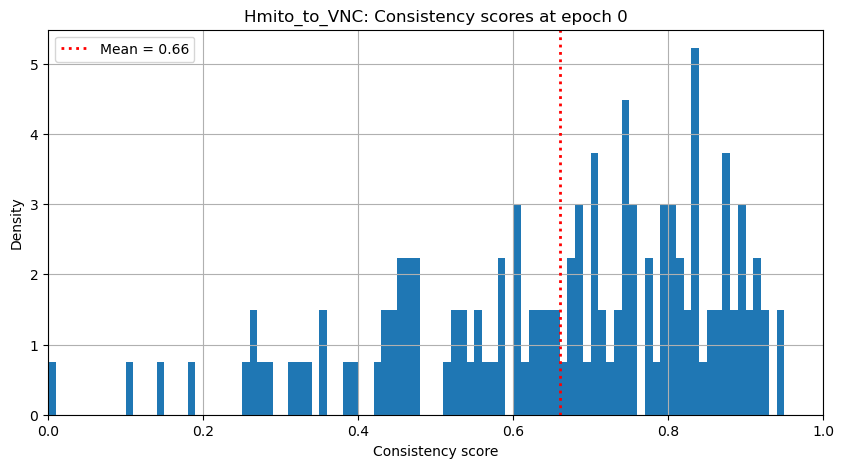

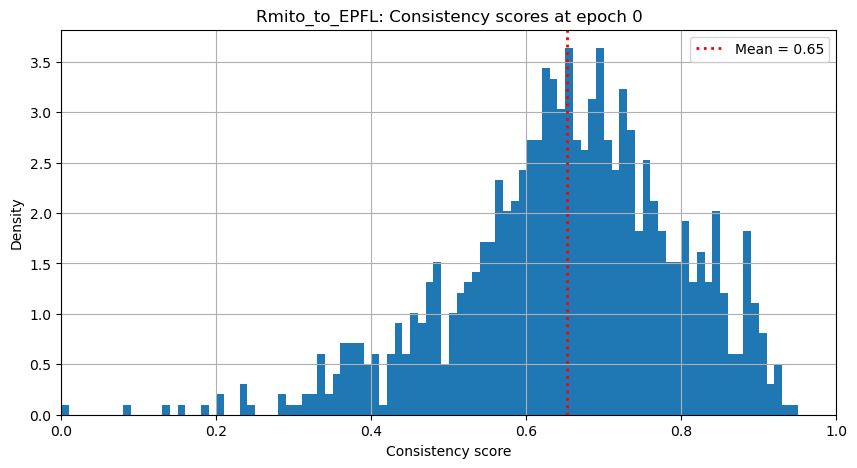

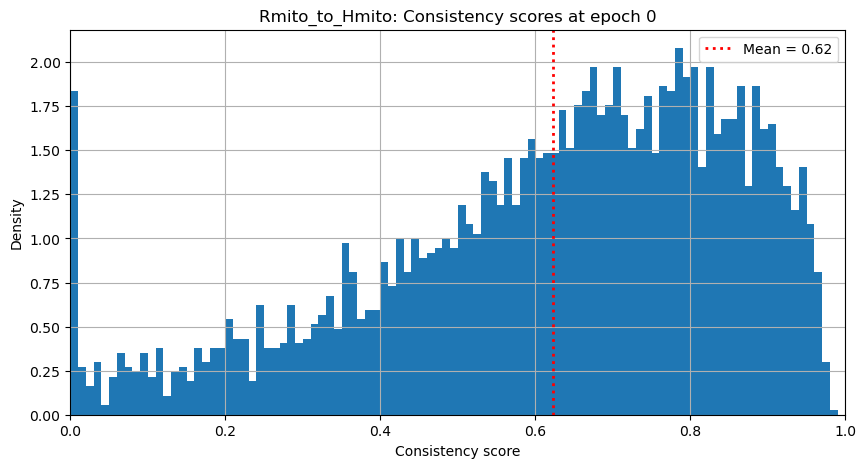

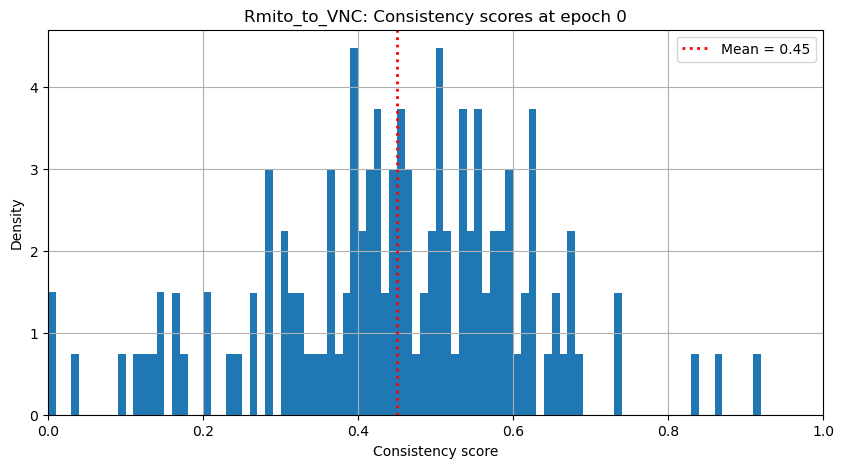

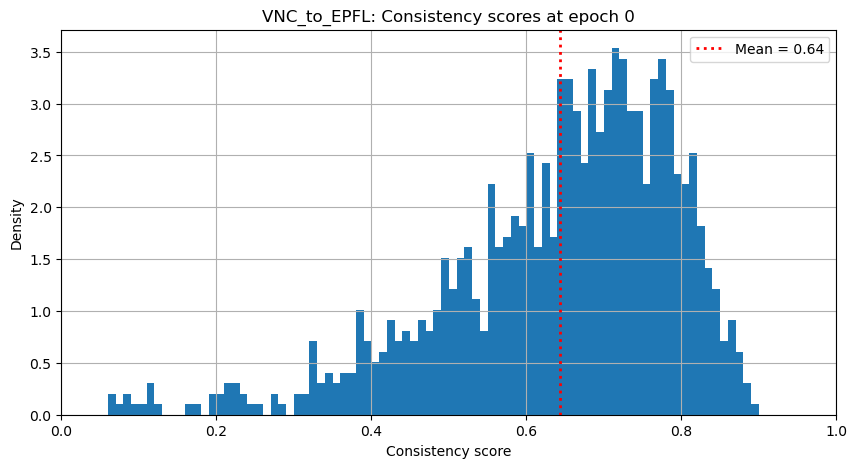

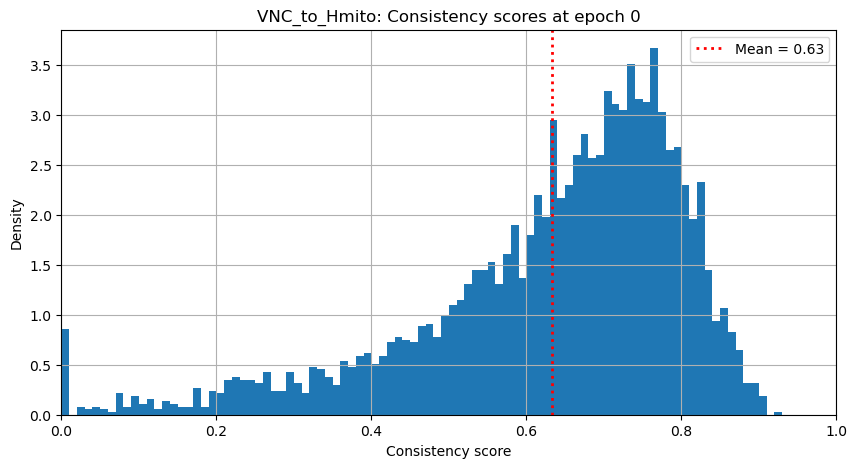

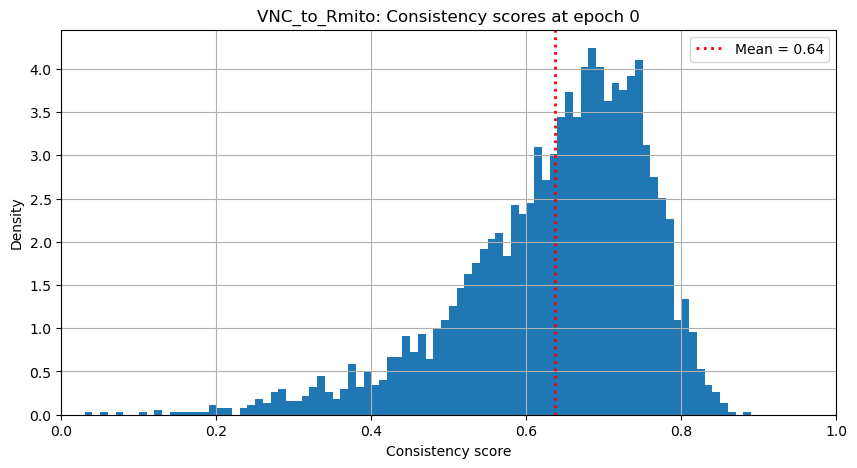

In [10]:
consis_dir = "09_consis_threshold_EI"
epochs: List[int] = [0]

for path in paths:
    transfer = find_transfer_from_pred_path(str(path))
    for epoch in epochs:
        if epoch == 0:
            ckpt_name = "best_checkpoint"
        else:
            ckpt_name = f"epoch-{epoch}"
        consis_path = path / consis_dir / f"patch_selection_{ckpt_name}.npz"
        if not consis_path.exists():
            print(f"File {consis_path} does not exist.")
            continue
        consis_scores = np.load(consis_path)["consis_scores"]
        assert is_ndarray(consis_scores), f"consis_scores should be a numpy array, got {type(consis_scores)}"
        mean_score = np.nanmean(consis_scores)
        _  = plt.figure(figsize=(10, 5))
        _ = plt.hist(consis_scores, bins=100, range=(0, 1), density=True)
        _ = plt.axvline(mean_score, color='r', linestyle='dotted', linewidth=2, label=f'Mean = {mean_score:.2f}')
        _ = plt.title(f"{transfer}: Consistency scores at epoch {epoch}")
        _ = plt.xlabel("Consistency score")
        _ = plt.ylabel("Density")
        _ = plt.xlim(0, 1)
        _ = plt.grid()
        _ = plt.legend()
        _ = plt.show()



In [12]:
for path in paths[:1]:
    transfer = find_transfer_from_pred_path(str(path))
    for epoch in epochs:
        if epoch == 0:
            ckpt_name = "best_checkpoint"
        else:
            ckpt_name = f"epoch-{epoch}"
        consis_path = path / consis_dir / f"patch_selection_{ckpt_name}.npz"
        if not consis_path.exists():
            print(f"File {consis_path} does not exist.")
            continue
        consis_scores = np.load(consis_path)["consis_scores"]

In [16]:
nan_ids = np.where(np.isnan(consis_scores))[0].tolist()
print(len(nan_ids), "nan ids")

354 nan ids


In [19]:
min_consis_score = np.nanmin(consis_scores)
print("Minimum non-NaN consis_score:", min_consis_score)

Minimum non-NaN consis_score: 0.0


In [20]:
zero_ids = np.where(consis_scores == 0)[0].tolist()
print(len(zero_ids), "zero ids")

103 zero ids


# F1 vs Consistency

In [22]:
models_DO = [
    "EtoH_DO_a02_model1", 
    "EtoR_DO_a02_model1", 
    "EtoV_DO_a02_model1",
    "HtoE_DO_a02_model3",
    #"HtoE_DO_a04_model1",
    "HtoR_DO_a02_model1",
    "HtoV_DO_a02_model1",
    "RtoE_DO_a02_model1",
    "RtoH_DO_a02_model1",
    "RtoV_DO_a02_model1",
    "VtoE_DO_a02_model1",
    "VtoH_DO_a02_model1",
    "VtoR_DO_a02_model1",
]

pred_paths = find_finetuning_result_paths(models_DO, output_folder="train_predictions")

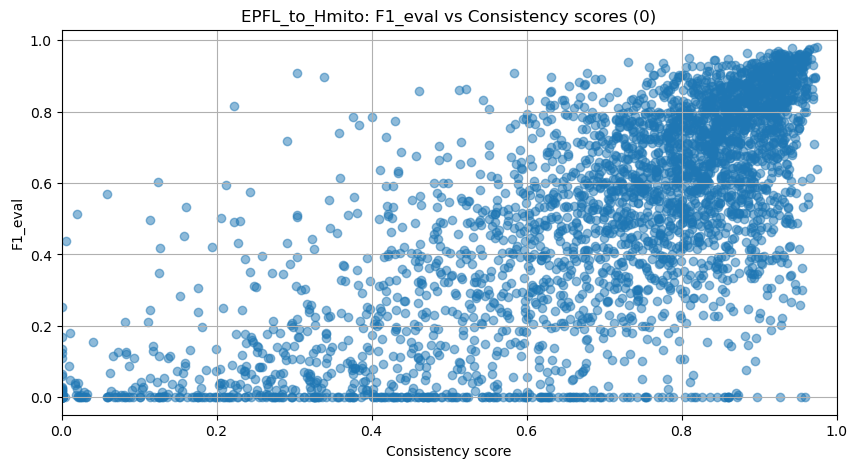

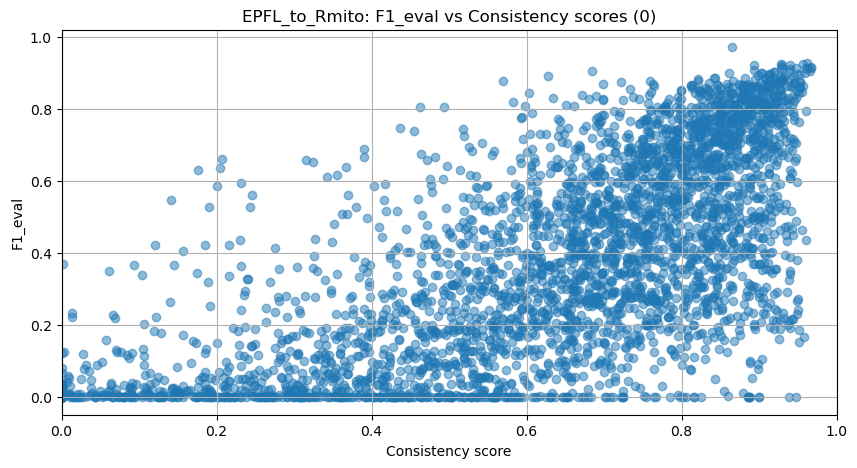

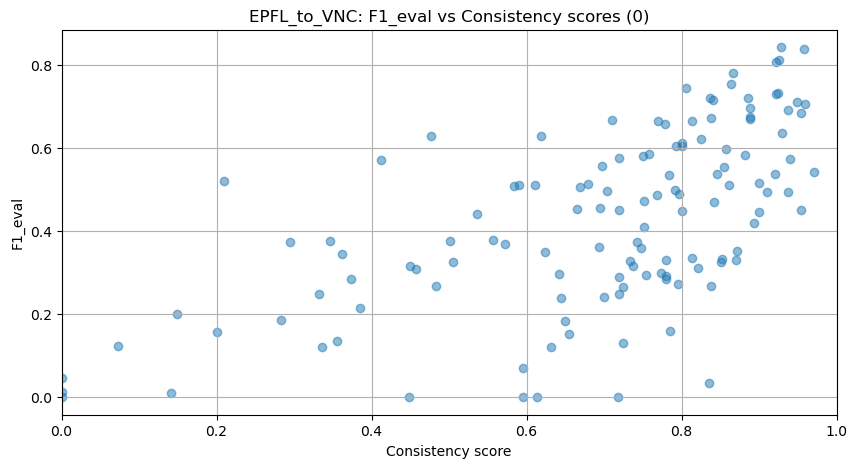

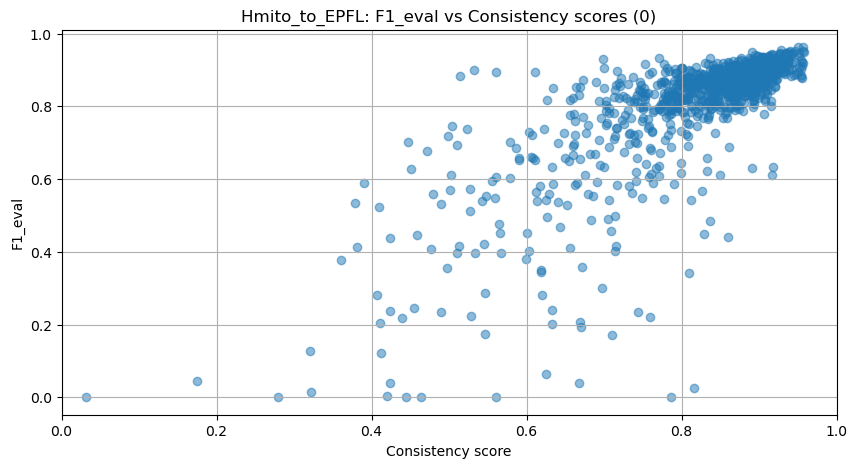

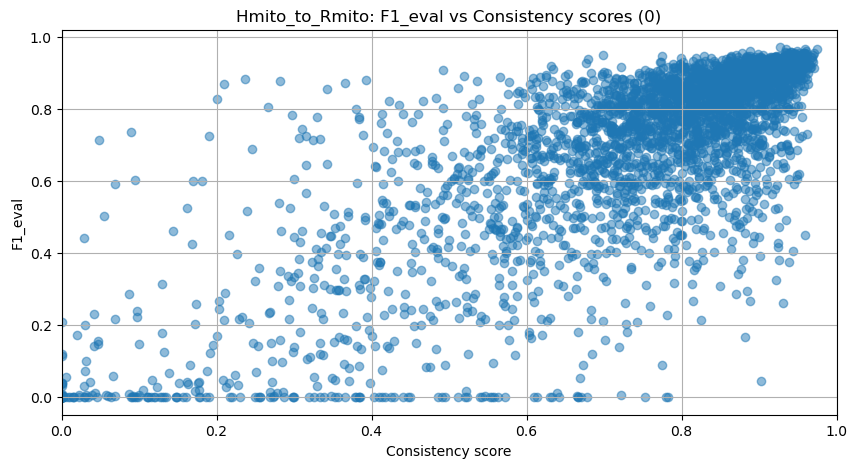

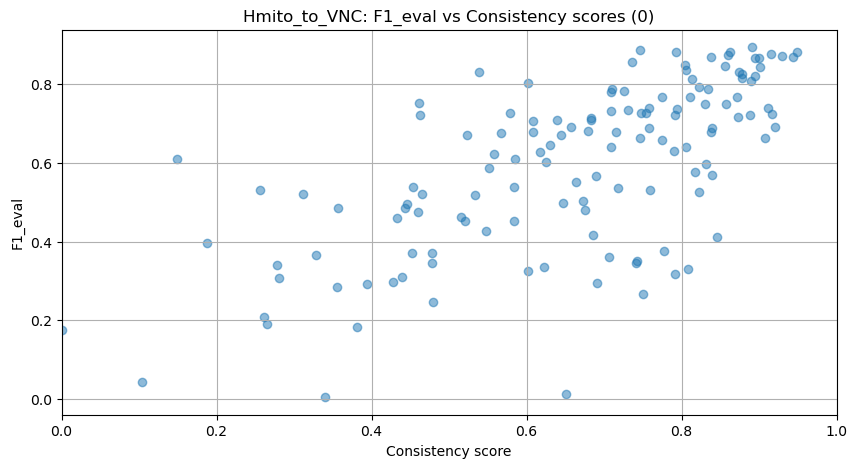

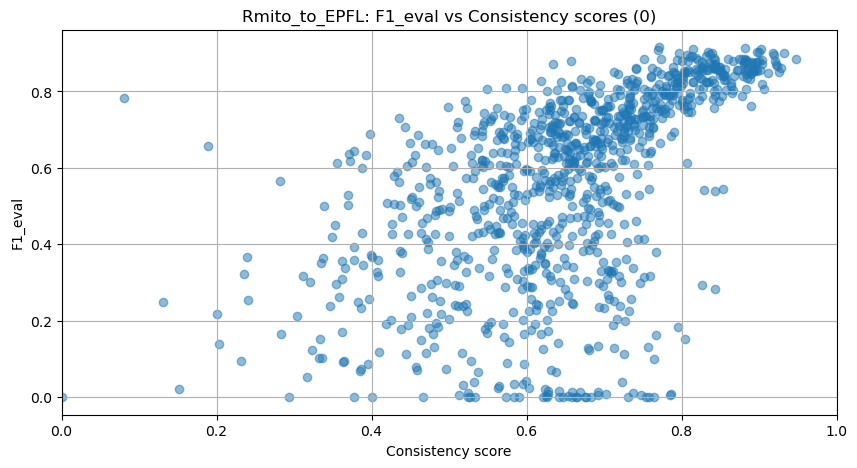

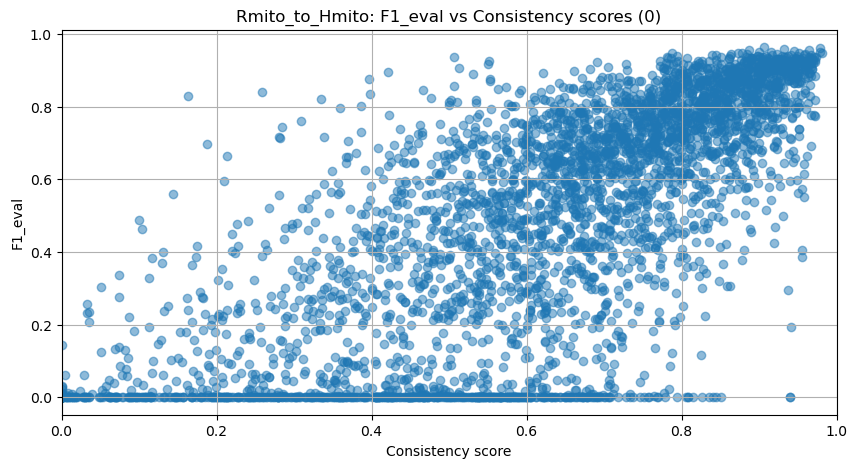

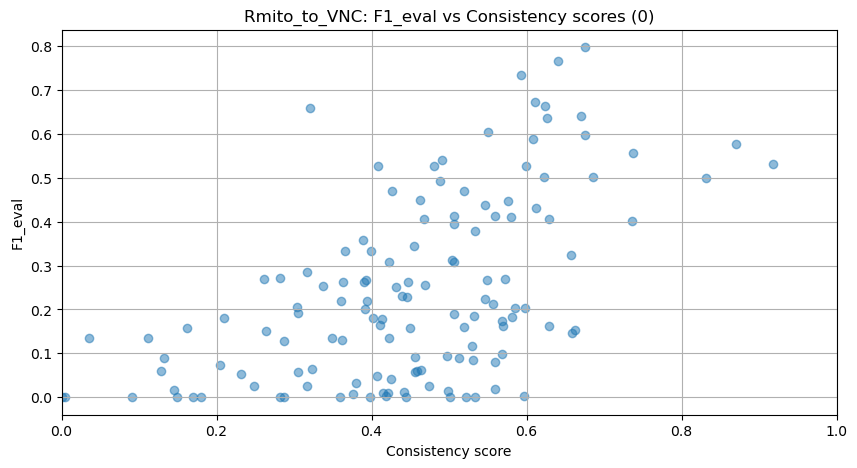

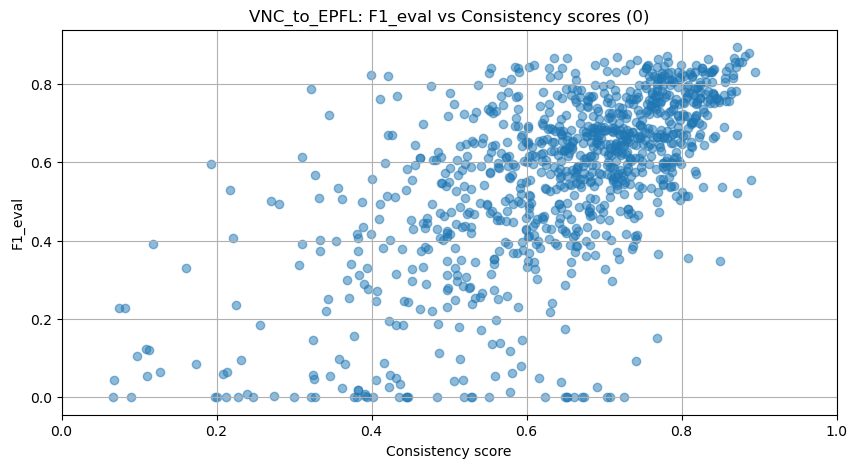

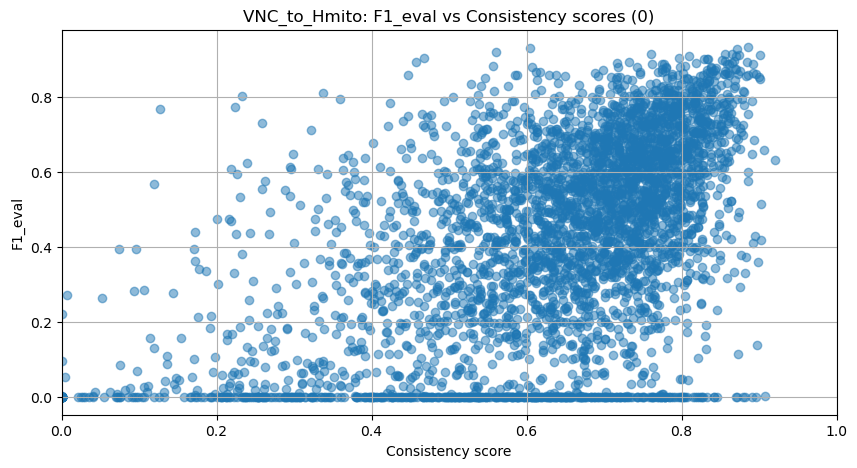

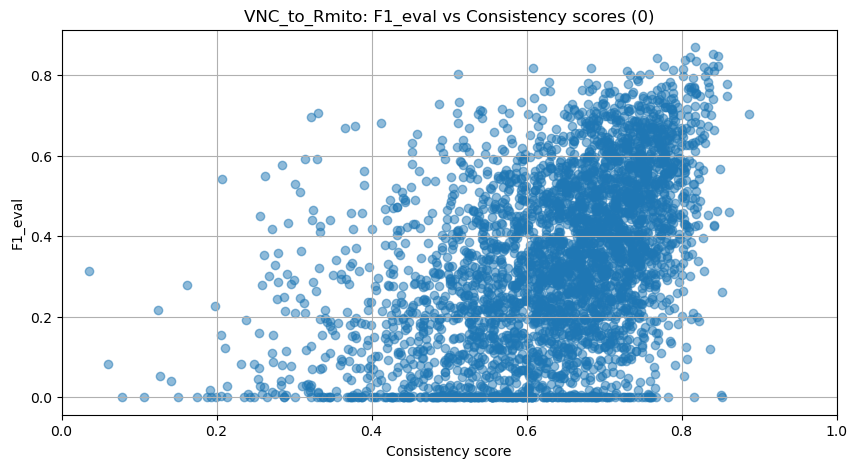

In [24]:
epochs = [0]
consis_dir = "09_consis_threshold_EI"
eval_score_key = "F1_eval"
for model in models_DO:
    consis_root_path = find_finetuning_result_paths([model], output_folder="pseudo_labeler")[0]
    pred_root_path = find_finetuning_result_paths([model], output_folder="train_predictions")[0]
    transfer = find_transfer_from_pred_path(str(consis_root_path))
    for epoch in epochs:
        if epoch == 0:
            consis_ckpt_name = "best_checkpoint"
            pred_ckpt_name = "epoch-0"
        else:
            consis_ckpt_name = f"epoch-{epoch}"
            pred_ckpt_name = f"epoch-{epoch}"
        consis_path = consis_root_path / consis_dir / f"patch_selection_{consis_ckpt_name}.npz"
        if not consis_path.exists():
            print(f"File {consis_path} does not exist.")
            continue
        consis_scores = np.load(consis_path)["consis_scores"]
        assert is_ndarray(consis_scores), f"consis_scores should be a numpy array, got {type(consis_scores)}"
        mean_score = np.nanmean(consis_scores)
        pred_path = list((pred_root_path / pred_ckpt_name / "predictions").glob("*predictions.h5"))[0]
        eval_scores = load_h5(pred_path, key=eval_score_key)[:,1]
        assert is_ndarray(eval_scores), f"eval_scores should be a numpy array, got {type(eval_scores)}"
        assert len(consis_scores) == len(eval_scores), f"Length mismatch: {len(consis_scores)} vs {len(eval_scores)}"
        _ = plt.figure(figsize=(10, 5))
        _ = plt.scatter(consis_scores, eval_scores, alpha=0.5)
        _ = plt.title(f"{transfer}: {eval_score_key} vs Consistency scores ({epoch})")
        _ = plt.xlabel("Consistency score")
        _ = plt.ylabel(eval_score_key)
        _ = plt.xlim(0, 1)
        _ = plt.grid()
        plt.show()

# weighted by object size

### Foreground Proportions GT

In [1]:
from model_ranking.datasets import get_datasets
from model_ranking.dataclass import (
    HmitoTargetConfig,
    RmitoTargetConfig,
    EPFLTargetConfig,
    VNCTargetConfig,
)

Hmito_dataset, _ = get_datasets(
    HmitoTargetConfig(),
    "train"
)

INFO: P [MainThread] 2025-06-17 10:10:47,816 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg
2025-06-17 10:10:51,786 [MainThread] INFO HDF5Dataset - Loading train set from: /scratch/talks/data/Hmito/train.h5...
2025-06-17 10:10:51,787 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 145.08239663085936, global std: 48.57221913786601
2025-06-17 10:11:53,362 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 0, 0)}
2025-06-17 10:11:53,393 [MainThread] INFO HDF5Dataset - Number of patches: 3750


In [2]:
Rmito_dataset, _ = get_datasets(
    RmitoTargetConfig(),
    "train"
)

2025-06-17 10:11:53,419 [MainThread] INFO HDF5Dataset - Loading train set from: /scratch/talks/data/Rmito/train.h5...
2025-06-17 10:11:53,419 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 130.19638966471354, global std: 64.19448665182877
2025-06-17 10:12:45,590 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 0, 0)}
2025-06-17 10:12:45,598 [MainThread] INFO HDF5Dataset - Number of patches: 3750


In [3]:
EPFL_dataset, _ = get_datasets(
    EPFLTargetConfig(),
    "train"
)

2025-06-17 10:12:45,616 [MainThread] INFO HDF5Dataset - Loading train set from: /scratch/talks/data/EPFL/train.h5...
2025-06-17 10:12:45,616 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.5509082674980164, global std: 0.11770268529653549
2025-06-17 10:12:46,098 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 32, 32)}
2025-06-17 10:12:46,354 [MainThread] INFO HDF5Dataset - Number of patches: 990


In [4]:
VNC_dataset, _ = get_datasets(
    VNCTargetConfig(),
    "train"
)

2025-06-17 10:12:46,361 [MainThread] INFO HDF5Dataset - Loading train set from: /scratch/talks/data/VNC/resized_pixels/train.h5...
2025-06-17 10:12:46,361 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.5043566823005676, global std: 0.21172188222408295
2025-06-17 10:12:46,398 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 256, 256), 'stride_shape': (1, 256, 256), 'halo_shape': (0, 0, 0)}
2025-06-17 10:12:46,401 [MainThread] INFO HDF5Dataset - Number of patches: 135


In [21]:
from typing import Union, Any
import numpy as np
from numpy.typing import NDArray
import torch

def proportion_nonzero(img: Union[torch.Tensor, NDArray[Any]]) -> float:
    """
    Returns the proportion of nonzero elements in the input image.
    Supports both torch.Tensor and numpy.ndarray.
    """
    if isinstance(img, torch.Tensor):
        return (img != 0).sum().item() / img.numel()
    elif isinstance(img, np.ndarray):
        return np.count_nonzero(img) / img.size
    else:
        raise TypeError(f"Unsupported type: {type(img)}")

In [27]:
b = torch.zeros((1, 1, 256, 256))
print(b.numel())

65536


In [32]:
a = np.ones((1, 1, 256, 256))
print(a.size)
b = (a > 0.5).astype(a.dtype)
print(b.shape)
print(b.dtype)

65536
(1, 1, 256, 256)
float64


In [26]:
256*256

65536

In [12]:
VNC_foreground_proportions = []
for dataset in VNC_dataset:
    for i in range(len(dataset)):
        _, label = dataset[i]
        VNC_foreground_proportions.append(proportion_nonzero(label))

In [13]:
EPFL_foreground_proportions = []
for dataset in EPFL_dataset:
    for i in range(len(dataset)):
        _, label = dataset[i]
        EPFL_foreground_proportions.append(proportion_nonzero(label))

In [14]:
Hmito_foreground_proportions = []
for dataset in Hmito_dataset:
    for i in range(len(dataset)):
        _, label = dataset[i]
        Hmito_foreground_proportions.append(proportion_nonzero(label))

In [15]:
Rmito_foreground_proportions = []
for dataset in Rmito_dataset:
    for i in range(len(dataset)):
        _, label = dataset[i]
        Rmito_foreground_proportions.append(proportion_nonzero(label))

In [18]:
from typing import Dict, List
fore_proportions: Dict[str, List[float]] = {
    "VNC": VNC_foreground_proportions,
    "EPFL": EPFL_foreground_proportions,
    "Hmito": Hmito_foreground_proportions,
    "Rmito": Rmito_foreground_proportions,
}

### Plot consistency vs F1

In [16]:
models_DO = [
    "EtoH_DO_a02_model1", 
    "EtoR_DO_a02_model1", 
    "EtoV_DO_a02_model1",
    "HtoE_DO_a02_model3",
    "HtoR_DO_a02_model1",
    "HtoV_DO_a02_model1",
    "RtoE_DO_a02_model1",
    "RtoH_DO_a02_model1",
    "RtoV_DO_a02_model1",
    "VtoE_DO_a02_model1",
    "VtoH_DO_a02_model1",
    "VtoR_DO_a02_model1",
]

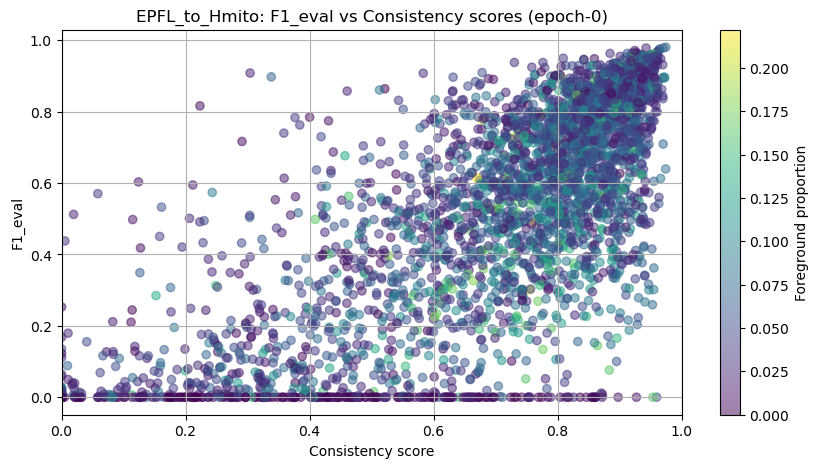

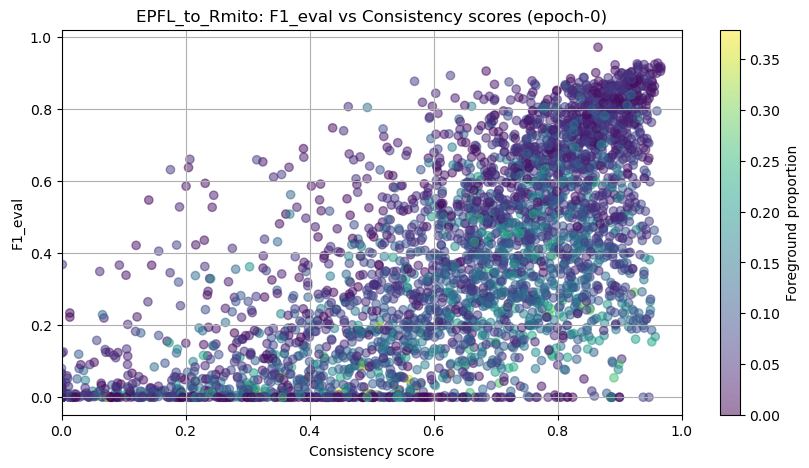

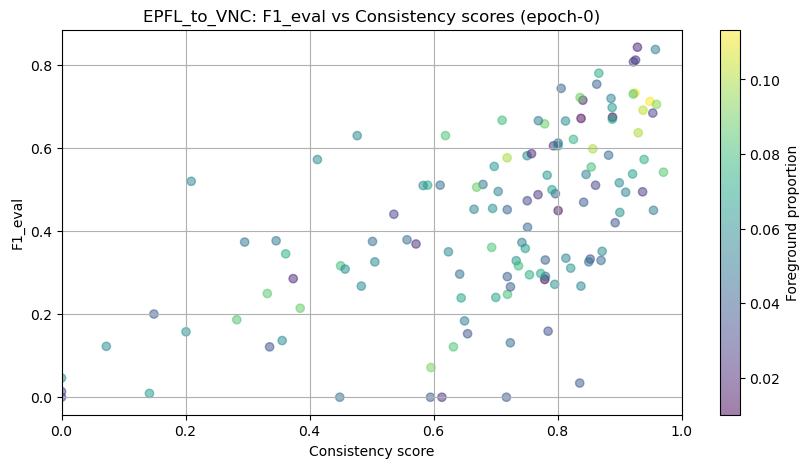

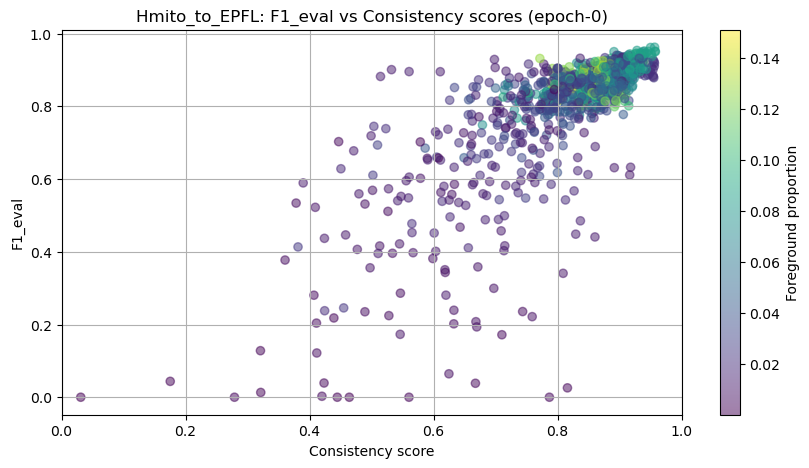

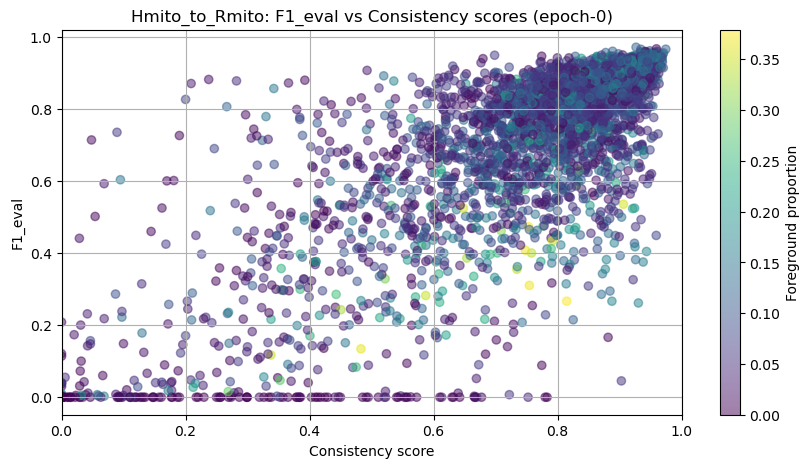

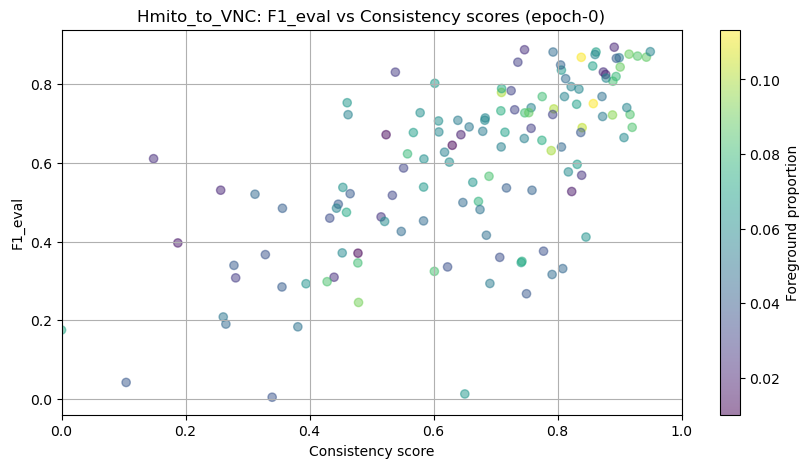

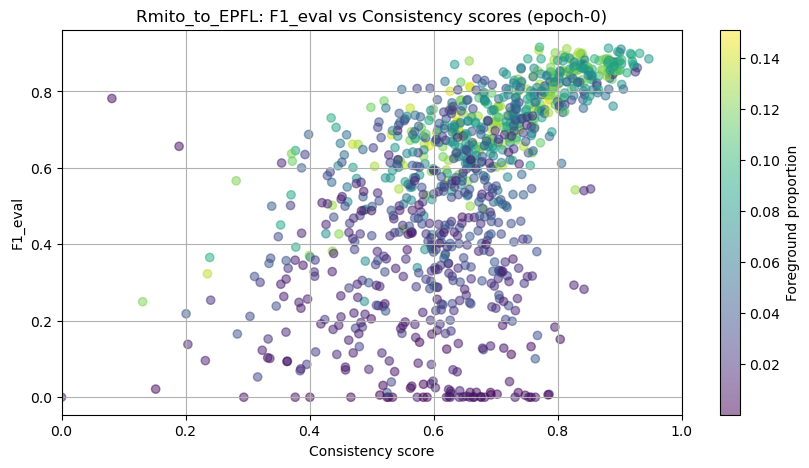

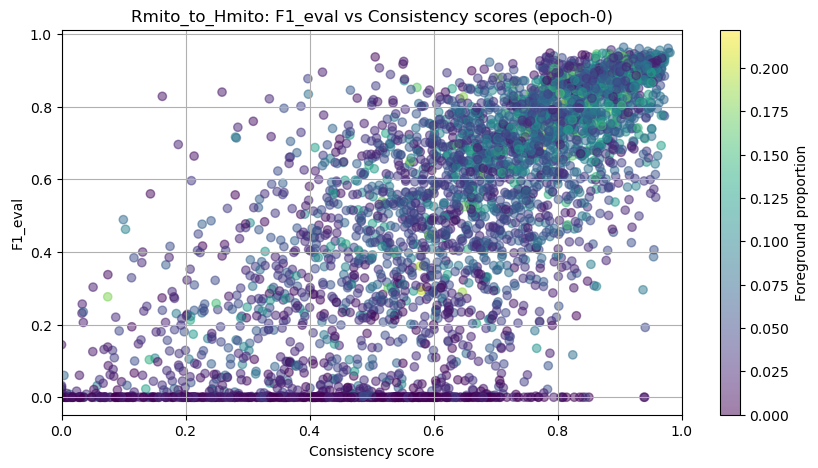

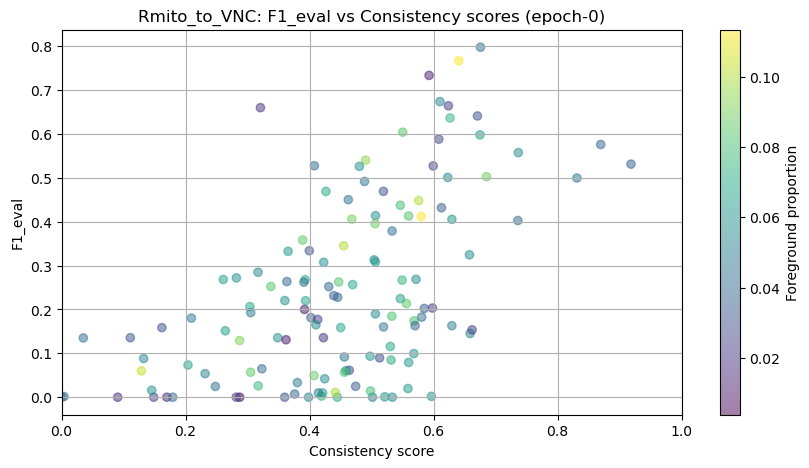

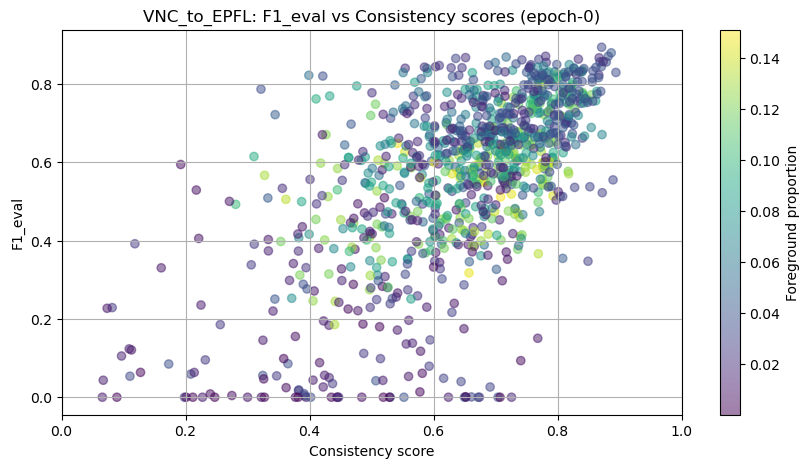

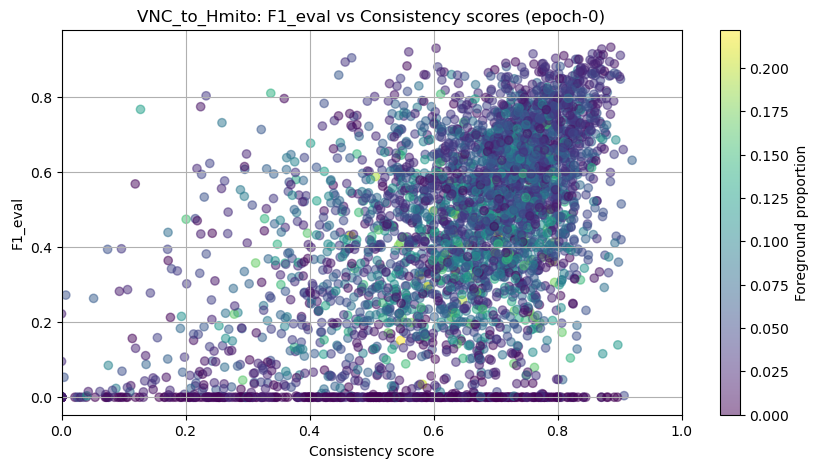

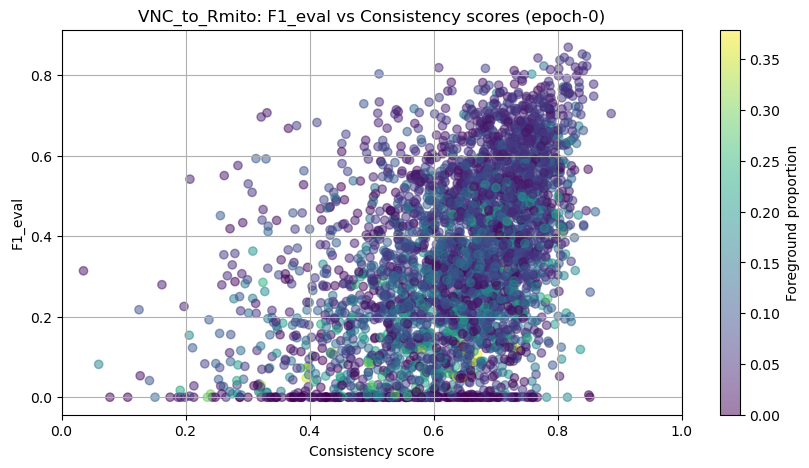

In [22]:
epochs = [0]
consis_dir = "09_consis_threshold_EI"
eval_score_key = "F1_eval"
for model in models_DO:
    consis_root_path = find_finetuning_result_paths([model], output_folder="pseudo_labeler")[0]
    pred_root_path = find_finetuning_result_paths([model], output_folder="train_predictions")[0]
    transfer = find_transfer_from_pred_path(str(consis_root_path))
    target = transfer.split("_to_")[-1]
    for epoch in epochs:
        if epoch == 0:
            consis_ckpt_name = "best_checkpoint"
            pred_ckpt_name = "epoch-0"
        else:
            consis_ckpt_name = f"epoch-{epoch}"
            pred_ckpt_name = f"epoch-{epoch}"
        consis_path = consis_root_path / consis_dir / f"patch_selection_{consis_ckpt_name}.npz"
        if not consis_path.exists():
            print(f"File {consis_path} does not exist.")
            continue
        consis_scores = np.load(consis_path)["consis_scores"]
        assert is_ndarray(consis_scores), f"consis_scores should be a numpy array, got {type(consis_scores)}"
        mean_score = np.nanmean(consis_scores)
        pred_path = list((pred_root_path / pred_ckpt_name / "predictions").glob("*predictions.h5"))[0]
        eval_scores = load_h5(pred_path, key=eval_score_key)[:,1]
        assert is_ndarray(eval_scores), f"eval_scores should be a numpy array, got {type(eval_scores)}"
        assert len(consis_scores) == len(eval_scores), f"Length mismatch: {len(consis_scores)} vs {len(eval_scores)}"
        _ = plt.figure(figsize=(10, 5))
        sc = plt.scatter(consis_scores, eval_scores, c=fore_proportions[target], cmap='viridis', alpha=0.5)
        _ = plt.title(f"{transfer}: {eval_score_key} vs Consistency scores (epoch-{epoch})")
        _ = plt.xlabel("Consistency score")
        _ = plt.ylabel(eval_score_key)
        _ = plt.xlim(0, 1)
        _ = plt.grid()
        _ = plt.colorbar(sc, label="Foreground proportion")
        plt.show()

# Foreground proportions -- predictions

In [22]:
models_DO = [
    "EtoH_DO_a02_model1", 
    "EtoR_DO_a02_model1", 
    "EtoV_DO_a02_model1",
    "HtoE_DO_a02_model3",
    "HtoR_DO_a02_model1",
    "HtoV_DO_a02_model1",
    "RtoE_DO_a02_model1",
    "RtoH_DO_a02_model1",
    "RtoV_DO_a02_model1",
    "VtoE_DO_a02_model1",
    "VtoH_DO_a02_model1",
    "VtoR_DO_a02_model1",
]

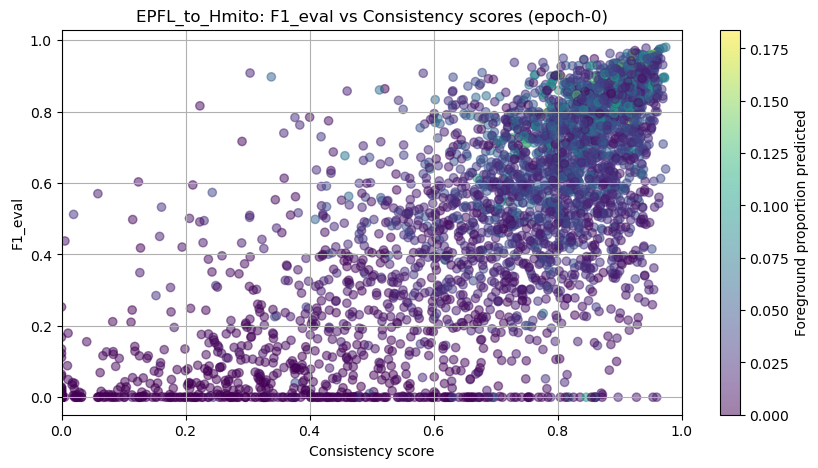

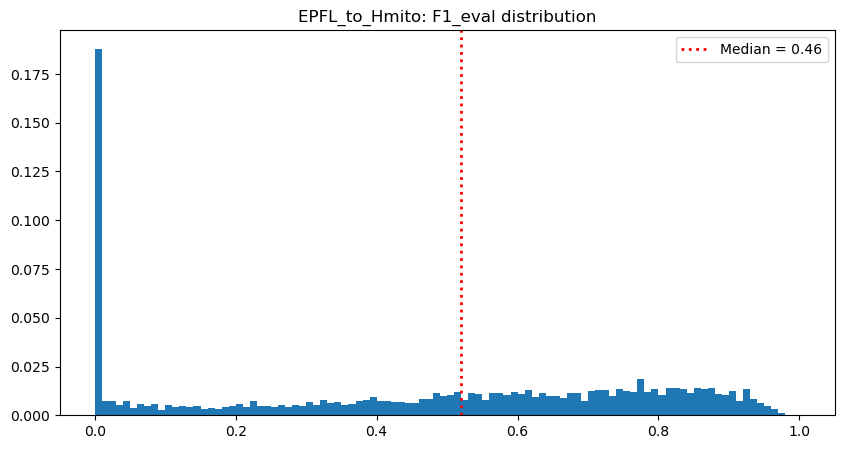

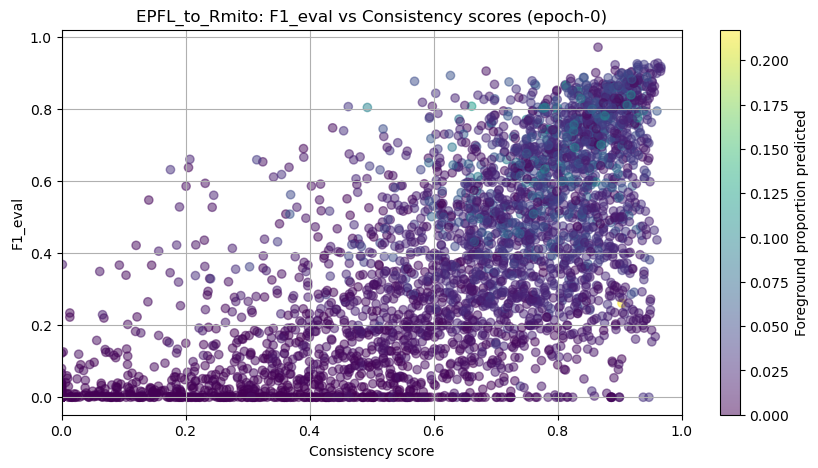

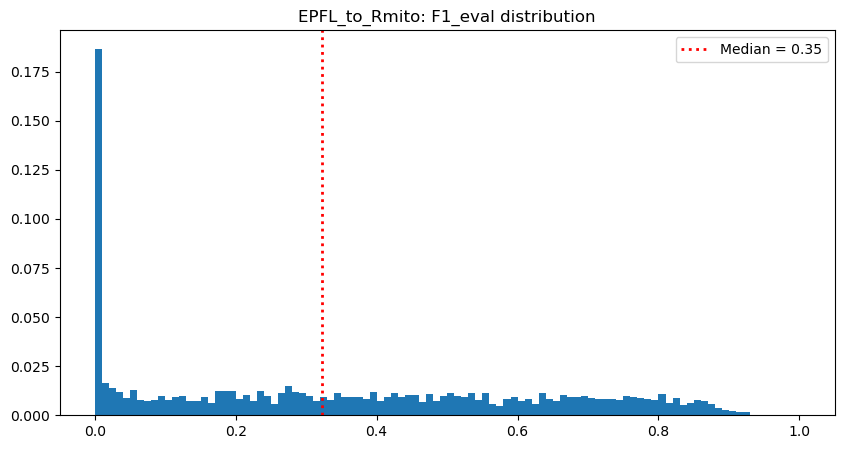

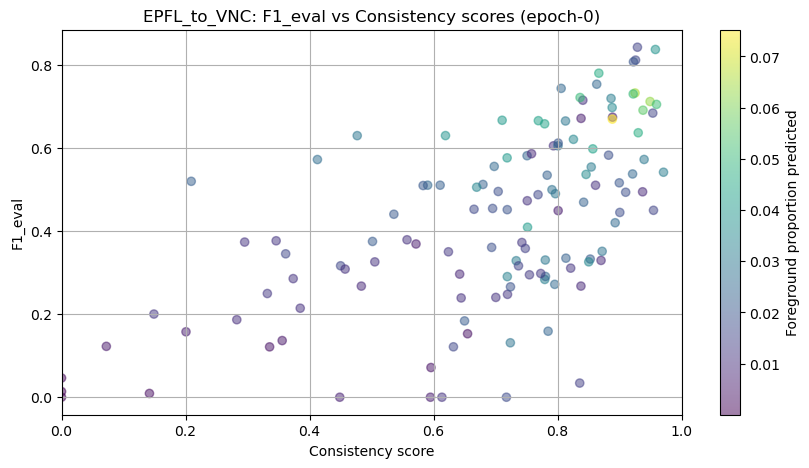

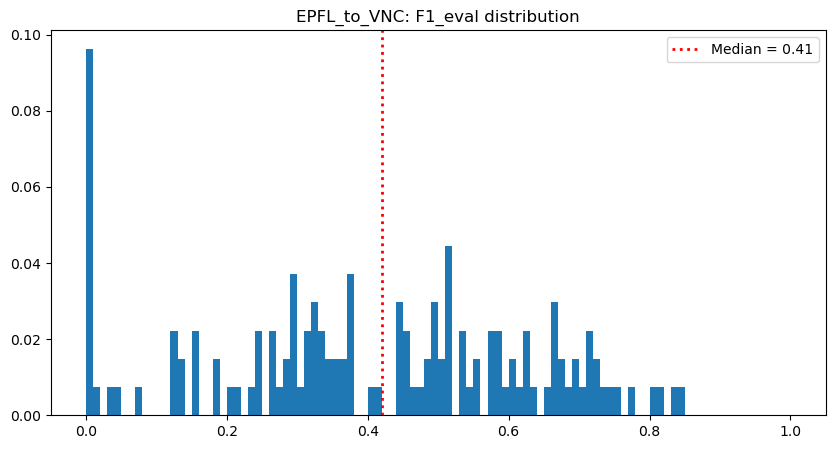

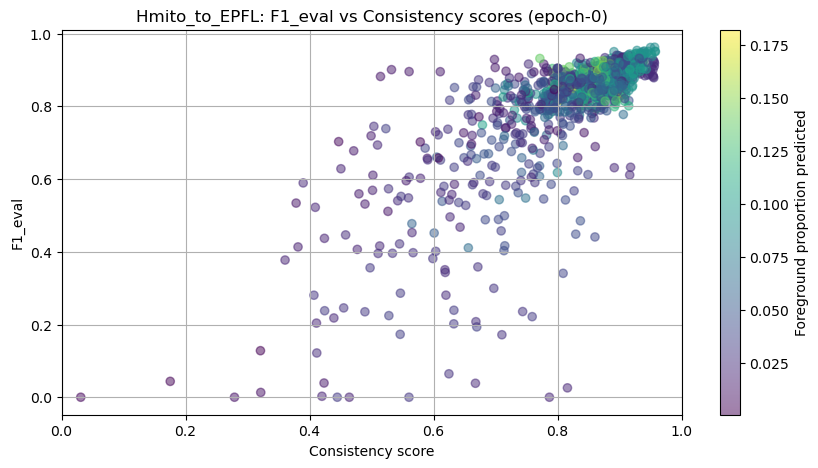

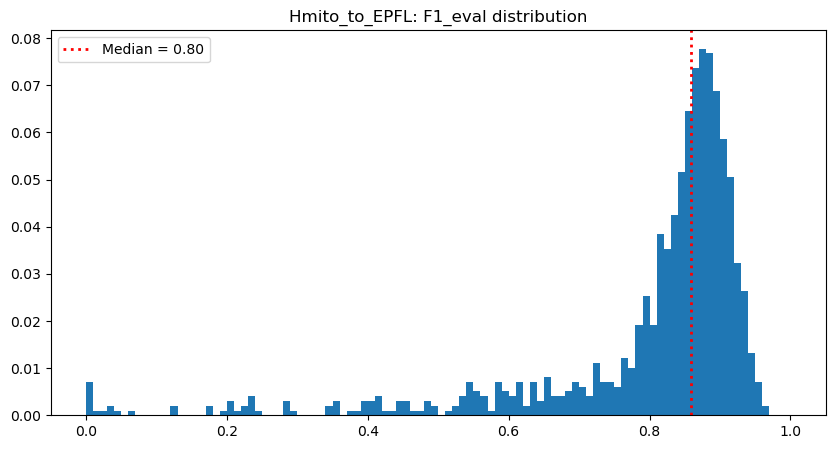

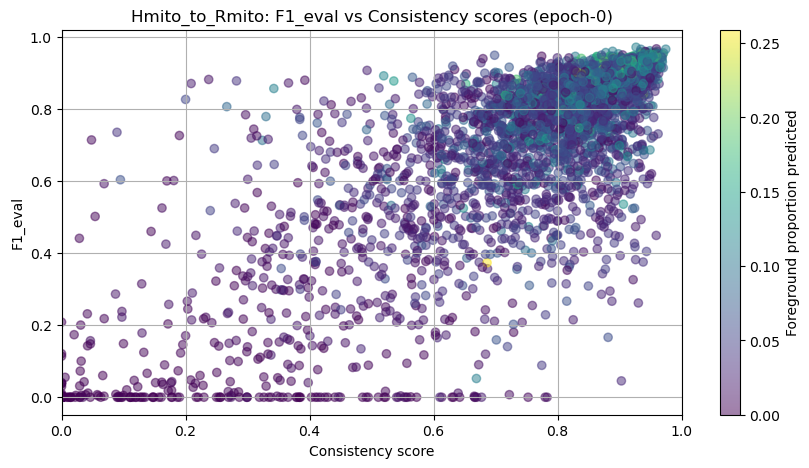

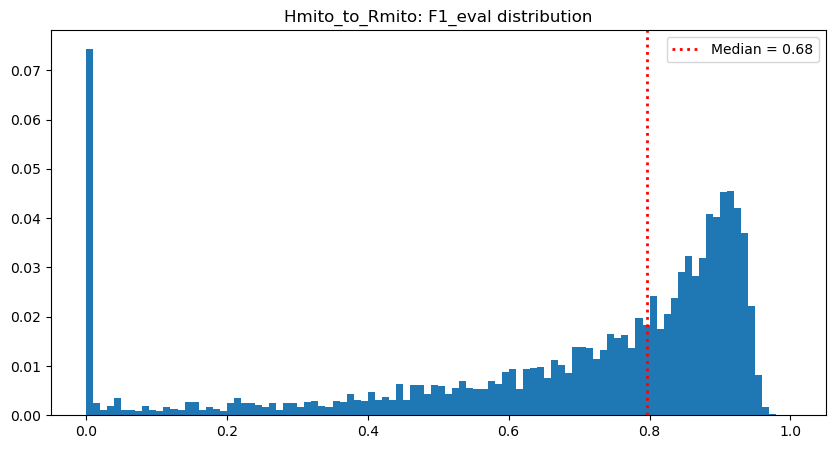

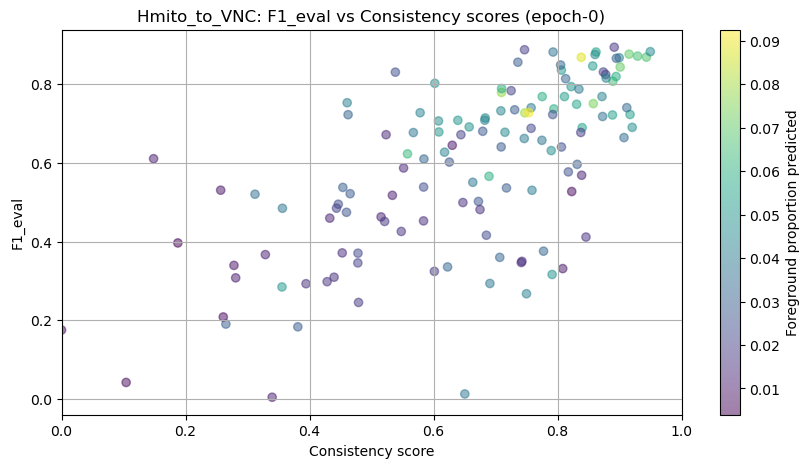

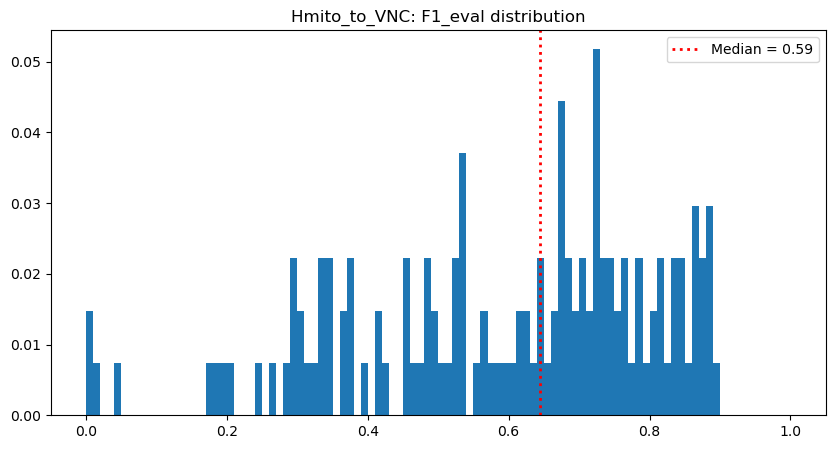

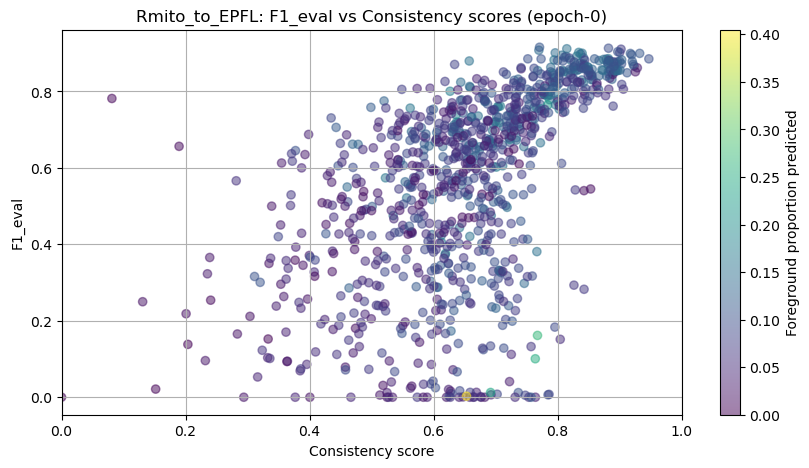

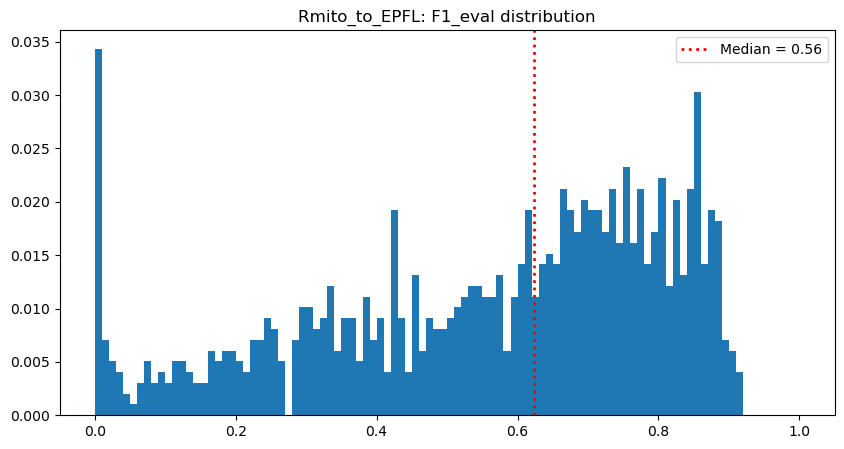

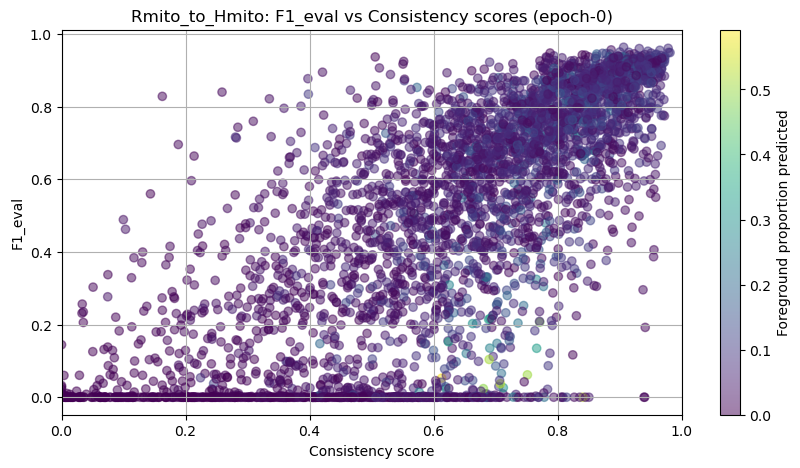

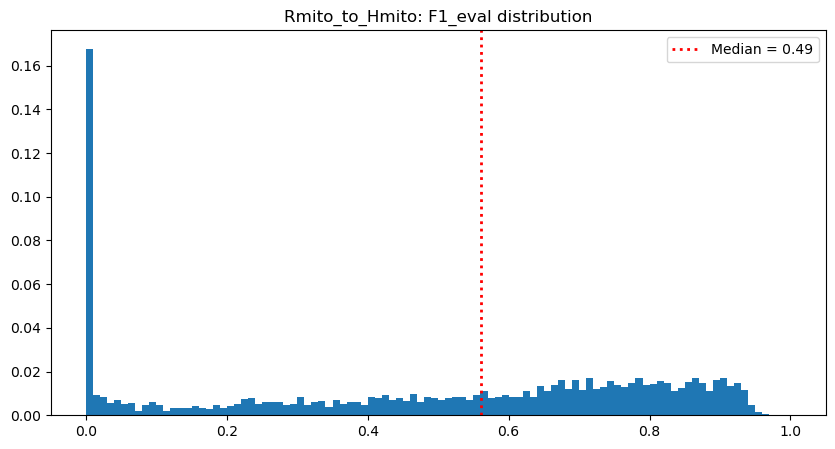

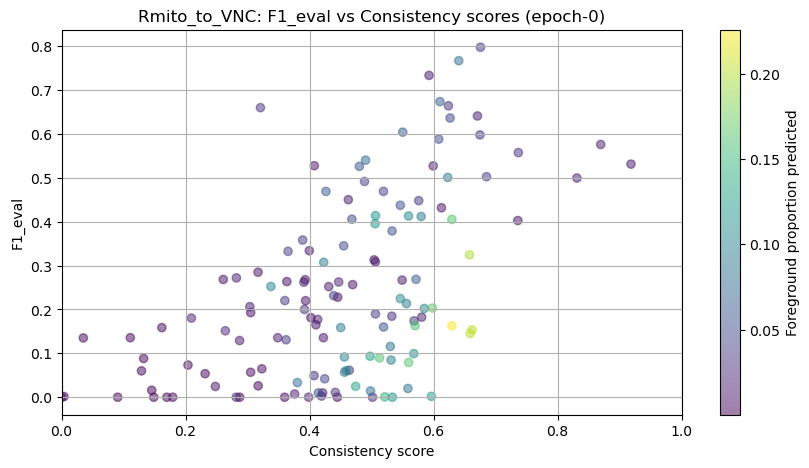

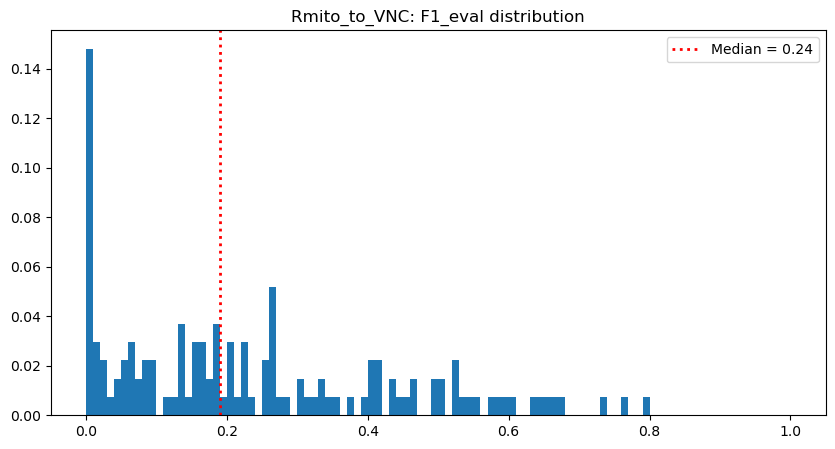

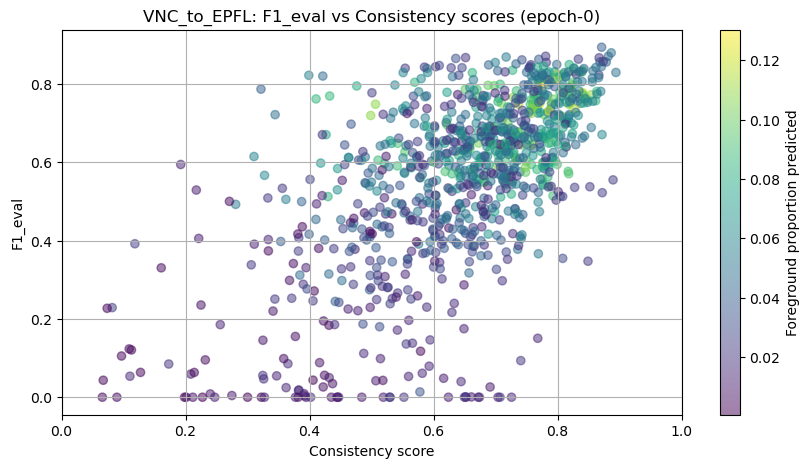

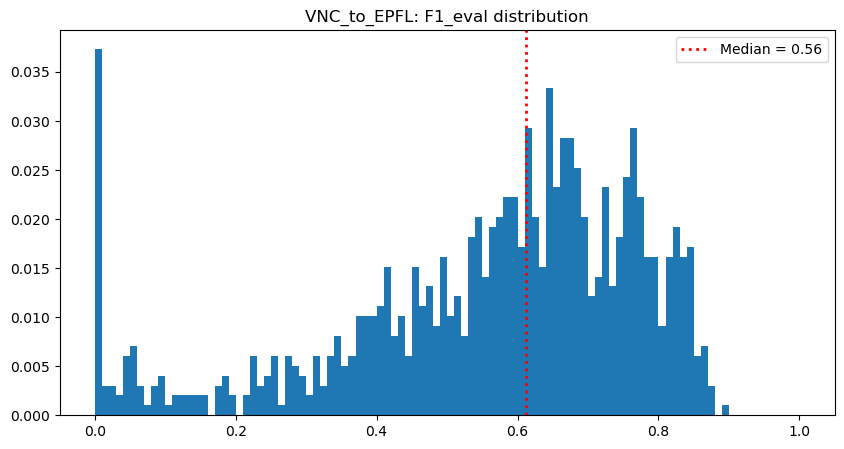

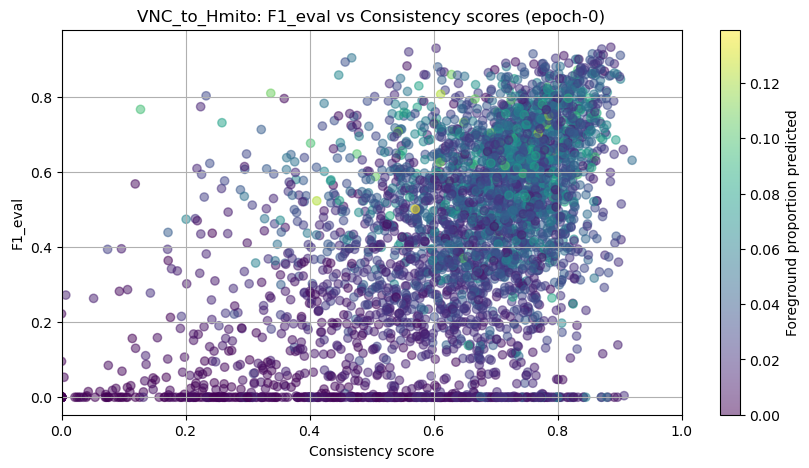

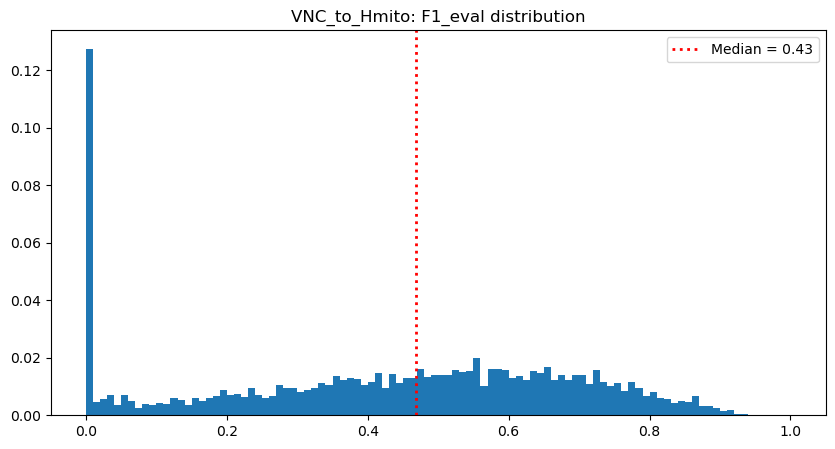

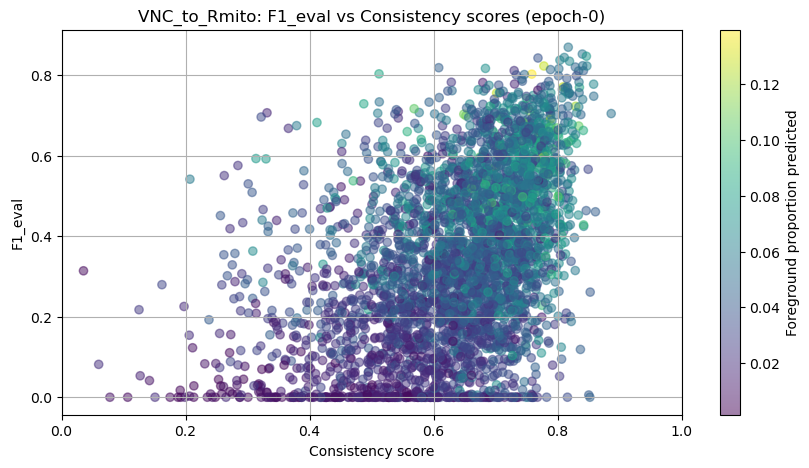

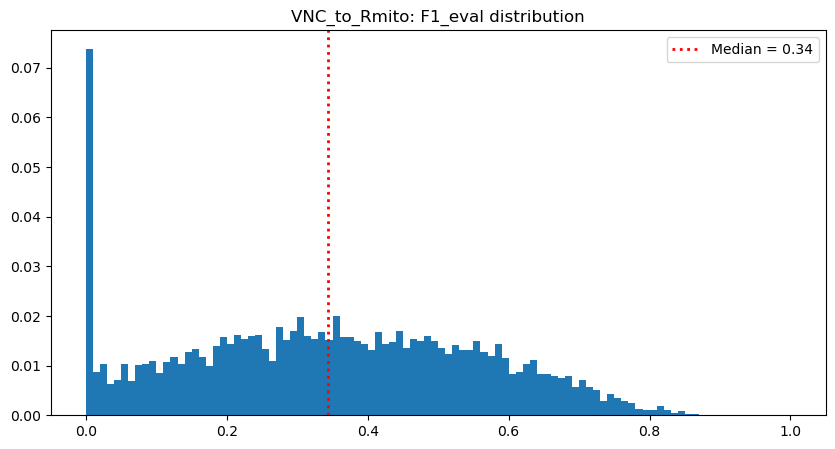

In [23]:
epochs = [0]
consis_dir = "09_consis_threshold_EI"
eval_score_key = "F1_eval"
foreground_threshold = 0.5
for model in models_DO:
    consis_root_path = find_finetuning_result_paths([model], output_folder="pseudo_labeler")[0]
    pred_root_path = find_finetuning_result_paths([model], output_folder="train_predictions")[0]
    transfer = find_transfer_from_pred_path(str(consis_root_path))
    target = transfer.split("_to_")[-1]
    for epoch in epochs:
        if epoch == 0:
            consis_ckpt_name = "best_checkpoint"
            pred_ckpt_name = "epoch-0"
        else:
            consis_ckpt_name = f"epoch-{epoch}"
            pred_ckpt_name = f"epoch-{epoch}"
        consis_path = consis_root_path / consis_dir / f"patch_selection_{consis_ckpt_name}.npz"
        if not consis_path.exists():
            print(f"File {consis_path} does not exist.")
            continue
        consis_scores = np.load(consis_path)["consis_scores"]
        assert is_ndarray(consis_scores), f"consis_scores should be a numpy array, got {type(consis_scores)}"
        mean_score = np.nanmean(consis_scores)
        pred_path = list((pred_root_path / pred_ckpt_name / "predictions").glob("*predictions.h5"))[0]
        predictions = load_h5(pred_path, key="predictions")
        foreground_proportions: List[float] = []
        for pred in predictions:
            foreground_proportions.append(proportion_nonzero((pred>foreground_threshold).astype(pred.dtype)))
        eval_scores = load_h5(pred_path, key=eval_score_key)[:,1]
        assert is_ndarray(eval_scores), f"eval_scores should be a numpy array, got {type(eval_scores)}"
        assert len(consis_scores) == len(eval_scores), f"Length mismatch: {len(consis_scores)} vs {len(eval_scores)}"
        _ = plt.figure(figsize=(10, 5))
        sc = plt.scatter(consis_scores, eval_scores, c=foreground_proportions, cmap='viridis', alpha=0.5)
        _ = plt.title(f"{transfer}: {eval_score_key} vs Consistency scores (epoch-{epoch})")
        _ = plt.xlabel("Consistency score")
        _ = plt.ylabel(eval_score_key)
        _ = plt.xlim(0, 1)
        _ = plt.grid()
        _ = plt.colorbar(sc, label="Foreground proportion predicted")
        plt.show()
        _ = plt.figure(figsize=(10, 5))
        _ = plt.hist(eval_scores, bins=100, range=(0, 1), weights=np.ones_like(eval_scores) / len(eval_scores))
        _ = plt.axvline(np.nanmedian(eval_scores), color='r', linestyle='dotted', linewidth=2, label=f'Median = {np.nanmean(eval_scores):.2f}')
        _ = plt.legend()
        _ = plt.title(f"{transfer}: {eval_score_key} distribution")
        plt.show()

In [ ]:
model = "EtoH_DO_a02_model1"
eval_score_key = "F1_eval"
pred_root_path = find_finetuning_result_paths([model], output_folder="train_predictions")[0]
pred_ckpt_name = "epoch-0"
pred_path = list((pred_root_path / pred_ckpt_name / "predictions").glob("*predictions.h5"))[0]
eval_scores = load_h5(pred_path, key=eval_score_key)[:,1]

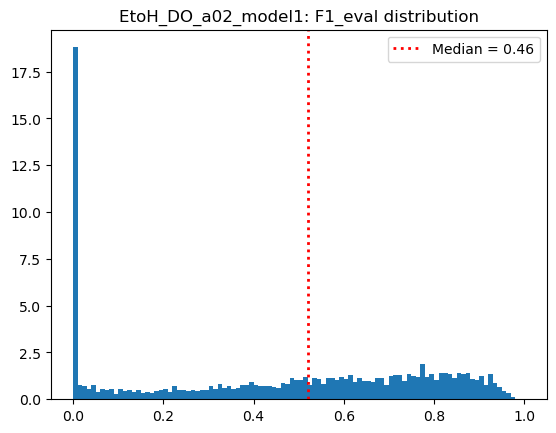

In [9]:
_= plt.hist(eval_scores, bins=100, range=(0, 1), density=True)
_ = plt.axvline(np.nanmedian(eval_scores), color='r', linestyle='dotted', linewidth=2, label=f'Median = {np.nanmean(eval_scores):.2f}')
_ = plt.legend()
_ = plt.title(f"{model}: {eval_score_key} distribution")

plt.show()

Median hard F1 score: 0.566


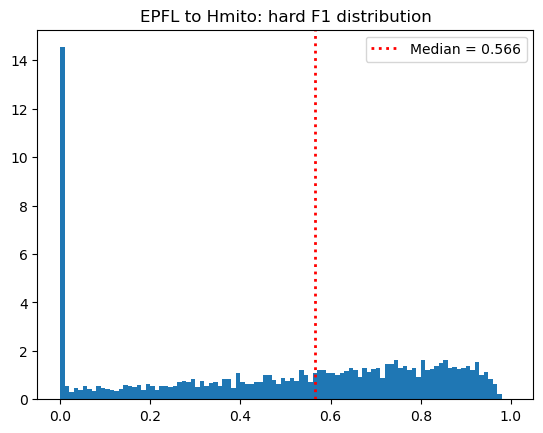

In [17]:
path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_Hmito_gap/feature_perturbation_consistency/FP_3/E_model4/norm_Normalize/none/predictions/test_converted_none.h5"
eval_scores = load_h5(path, key="hard_f1")[:,1]
median_f1 = np.nanmedian(eval_scores)
print(f"Median hard F1 score: {median_f1:.3f}")
_= plt.hist(eval_scores, bins=100, range=(0, 1), density=True)
_ = plt.axvline(median_f1, color='r', linestyle='dotted', linewidth=2, label=f'Median = {median_f1:.3f}')
_ = plt.legend()
_ = plt.title(f"EPFL to Hmito: hard F1 distribution")
plt.show()

In [14]:
path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/EPFL_to_Hmito_gap/feature_perturbation_consistency/FP_3/E_model4/norm_Normalize/none/predictions/test_converted_none.h5"
f1_scores = load_h5(path, key="hard_f1")[:,1]
print(f1_scores.shape)
print(np.median(f1_scores))

(3750,)
0.5659869


In [3]:
128*4

512